<a href="https://colab.research.google.com/github/ohood95/ohood95.github.io/blob/master/MyFER2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Facial Emotion Recognition
# Vision Transformer + Multi-Head Attention + Knowledge Distillation

**Dataset:** [Facial Emotion Dataset](https://www.kaggle.com/datasets/dilkushsingh/facial-emotion-dataset)  
**Target:** 90%+ Accuracy (with high-quality data)  
**Framework:** PyTorch + timm



## 1. Install Dependencies

In [ ]:
# Run this cell first — install required packages
# If you have GPU: uncomment the first line and comment the second

# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
#!pip install torch torchvision torchaudio
#!pip install timm==0.9.12
#!pip install scikit-learn matplotlib seaborn tqdm pandas opencv-python

# Optional — install if possible (the code works without it)
#!pip install albumentations --user
#!pip install facenet-pytorch --user

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Imports & Configuration

In [ ]:
import os
import sys
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

import torchvision.transforms as T
import timm

from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)
from sklearn.model_selection import StratifiedShuffleSplit

# ------- Optional: Albumentations (fallback to torchvision if not installed) -------
try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
    USE_ALBUMENTATIONS = True
    print("Albumentations: Available")
except ImportError:
    USE_ALBUMENTATIONS = False
    print("Albumentations: Not found -> using torchvision transforms (still works fine)")

# ------- Optional: MTCNN for Face Alignment -------
try:
    from facenet_pytorch import MTCNN
    MTCNN_AVAILABLE = True
    print("MTCNN: Available")
except ImportError:
    MTCNN_AVAILABLE = False
    print("MTCNN: Not found -> skipping face alignment")

# ------- Reproducibility -------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"\nPyTorch:  {torch.__version__}")
print(f"timm:     {timm.__version__}")
print(f"Device:   {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU:      {torch.cuda.get_device_name(0)}")
    print(f"VRAM:     {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Albumentations: Available
MTCNN: Not found -> skipping face alignment

PyTorch:  2.11.0+cu128
timm:     1.0.28
Device:   cuda
GPU:      NVIDIA A100-SXM4-40GB
VRAM:     42.4 GB


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CONFIGURATION — Update paths before running                ║
# ╚══════════════════════════════════════════════════════════════╝

class Config:
    # ------- Dataset paths (UPDATE THESE) -------
    TRAIN_DIR = '/content/drive/MyDrive/Emotion_dataset/train_dir'   # <<< UPDATE
    TEST_DIR  = '/content/drive/MyDrive/Emotion_dataset/test_dir'    # <<< UPDATE


    # ------- Model settings -------
    MODEL_NAME      = 'vit_base_patch16_224'  # Or 'vit_small_patch16_224' for less VRAM
    IMG_SIZE        = 224
    NUM_CLASSES     = 7
    BATCH_SIZE      = 32       # Reduce to 16 if you get OOM errors
    EPOCHS          = 40
    LR              = 3e-5
    WEIGHT_DECAY    = 0.05
    LABEL_SMOOTHING = 0.1
    MIXUP_ALPHA     = 0.4
    CUTMIX_ALPHA    = 1.0
    MIXUP_PROB      = 0.5      # Probability of applying Mixup/CutMix per batch

    # ------- Optimization toggles -------
    USE_FACE_ALIGN   = MTCNN_AVAILABLE
    USE_MIXED_PREC   = torch.cuda.is_available()  # Auto-enable on GPU
    USE_TTA          = True
    USE_ENSEMBLE     = True
    USE_DISTILLATION = True

    # ------- Emotion classes (match folder names) -------
    EMOTION_LABELS = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

    # ------- ImageNet normalization -------
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]


cfg = Config()

print("=" * 55)
print("  Configuration")
print("=" * 55)
print(f"  Model:           {cfg.MODEL_NAME}")
print(f"  Image Size:      {cfg.IMG_SIZE}x{cfg.IMG_SIZE}")
print(f"  Batch Size:      {cfg.BATCH_SIZE}")
print(f"  Epochs:          {cfg.EPOCHS}")
print(f"  Learning Rate:   {cfg.LR}")
print(f"  Label Smoothing: {cfg.LABEL_SMOOTHING}")
print(f"  Face Alignment:  {'ON' if cfg.USE_FACE_ALIGN else 'OFF'}")
print(f"  Mixed Precision: {'ON' if cfg.USE_MIXED_PREC else 'OFF'}")
print(f"  Augmentation:    {'Albumentations' if USE_ALBUMENTATIONS else 'torchvision'}")
print("=" * 55)

  Configuration
  Model:           vit_base_patch16_224
  Image Size:      224x224
  Batch Size:      32
  Epochs:          40
  Learning Rate:   3e-05
  Label Smoothing: 0.1
  Face Alignment:  OFF
  Mixed Precision: ON
  Augmentation:    Albumentations


## 3. Face Alignment (MTCNN)

Aligns detected faces so eyes and mouth are in consistent positions.  
This gives **+2-4% accuracy** because the model focuses on expressions, not head pose.

In [ ]:
class FaceAligner:
    """
    Face alignment using MTCNN.
    - Detects and crops face with margin
    - Falls back to simple resize if no face is detected
    - Caches results to avoid re-detection on same image
    """
    def __init__(self, target_size=224, margin=40, enabled=True):
        self.target_size = target_size
        self.margin = margin
        self.enabled = enabled
        self.cache = {}
        self.stats = {'detected': 0, 'fallback': 0}

        if enabled and MTCNN_AVAILABLE:
            self.detector = MTCNN(
                image_size=target_size,
                margin=margin,
                keep_all=False,
                min_face_size=20,
                device='cuda' if torch.cuda.is_available() else 'cpu',
                post_process=False
            )
            print("Face Aligner: ENABLED (MTCNN)")
        else:
            self.enabled = False
            self.detector = None
            print("Face Aligner: DISABLED (simple resize)")

    def align(self, image_rgb, cache_key=None):
        """Align a single RGB image (H, W, 3) with values 0-255."""
        if cache_key and cache_key in self.cache:
            return self.cache[cache_key]

        if not self.enabled:
            result = cv2.resize(image_rgb, (self.target_size, self.target_size))
            return result

        try:
            from PIL import Image
            pil_img = Image.fromarray(image_rgb)
            face_tensor = self.detector(pil_img)

            if face_tensor is not None:
                face_np = face_tensor.permute(1, 2, 0).cpu().numpy()
                face_np = np.clip(face_np, 0, 255).astype(np.uint8)
                face_np = cv2.resize(face_np, (self.target_size, self.target_size))
                self.stats['detected'] += 1
                if cache_key:
                    self.cache[cache_key] = face_np
                return face_np
        except Exception:
            pass

        # Fallback: simple resize
        self.stats['fallback'] += 1
        result = cv2.resize(image_rgb, (self.target_size, self.target_size))
        if cache_key:
            self.cache[cache_key] = result
        return result

    def print_stats(self):
        total = self.stats['detected'] + self.stats['fallback']
        if total > 0:
            pct = self.stats['detected'] / total * 100
            print(f"Face Alignment: {self.stats['detected']}/{total} detected ({pct:.1f}%)")


face_aligner = FaceAligner(
    target_size=cfg.IMG_SIZE,
    margin=40,
    enabled=cfg.USE_FACE_ALIGN
)

Face Aligner: DISABLED (simple resize)


## 4. Data Loading + Augmentation Pipeline

In [ ]:
# ================================================================
#  Load image paths and labels from folder structure
# ================================================================

def load_image_paths(directory, emotion_labels):
    """
    Load image paths and labels from:
      directory/angry/*.jpg, directory/happy/*.jpg, ...
    """
    paths, labels = [], []
    available = set(os.listdir(directory)) if os.path.exists(directory) else set()

    for idx, emotion in enumerate(emotion_labels):
        # Case-insensitive folder matching
        folder_name = None
        for f in available:
            if f.lower() == emotion.lower():
                folder_name = f
                break

        if folder_name is None:
            print(f"  WARNING: folder '{emotion}' not found in {directory}")
            continue

        folder_path = os.path.join(directory, folder_name)
        for fname in os.listdir(folder_path):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                paths.append(os.path.join(folder_path, fname))
                labels.append(idx)

    return paths, np.array(labels)


print("Loading training data...")
train_paths, train_labels = load_image_paths(cfg.TRAIN_DIR, cfg.EMOTION_LABELS)
print(f"  Found: {len(train_paths):,} images")

print("Loading test data...")
test_paths, test_labels = load_image_paths(cfg.TEST_DIR, cfg.EMOTION_LABELS)
print(f"  Found: {len(test_paths):,} images")

# Class distribution
dist = Counter(train_labels)
print(f"\n{'Emotion':<12} {'Train':>8} {'Test':>8}")
print("-" * 32)
for idx, emo in enumerate(cfg.EMOTION_LABELS):
    print(f"{emo:<12} {dist.get(idx,0):>8,} {Counter(test_labels).get(idx,0):>8,}")
print("-" * 32)
print(f"{'TOTAL':<12} {len(train_labels):>8,} {len(test_labels):>8,}")

Loading training data...
  Found: 29,432 images
Loading test data...
  Found: 7,340 images

Emotion         Train     Test
--------------------------------
angry           3,880      971
disgust         2,324      567
fear            3,654      911
happy           6,410    1,599
neutral         5,036    1,259
sad             4,959    1,240
surprise        3,169      793
--------------------------------
TOTAL          29,432    7,340


In [ ]:
# ================================================================
#  Stratified Train / Validation split
# ================================================================

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.12, random_state=SEED)
tr_idx, vl_idx = next(sss.split(train_paths, train_labels))

tr_paths  = [train_paths[i] for i in tr_idx]
tr_labels = train_labels[tr_idx]
vl_paths  = [train_paths[i] for i in vl_idx]
vl_labels = train_labels[vl_idx]

print(f"Train: {len(tr_paths):,} | Val: {len(vl_paths):,} | Test: {len(test_paths):,}")

Train: 25,900 | Val: 3,532 | Test: 7,340


In [ ]:
# ================================================================
#  Augmentation Pipelines (Albumentations OR torchvision)
# ================================================================

if USE_ALBUMENTATIONS:
    # ---------- Albumentations (preferred) ----------
    def get_train_transforms(img_size=224):
        return A.Compose([
            A.Resize(img_size, img_size),
            A.CLAHE(clip_limit=2.0, tile_grid_size=(4, 4), p=0.5),
            A.HorizontalFlip(p=0.5),
            A.ShiftScaleRotate(
                shift_limit=0.08, scale_limit=0.12, rotate_limit=12,
                border_mode=cv2.BORDER_CONSTANT, p=0.6
            ),
            A.GridDistortion(num_steps=5, distort_limit=0.08, p=0.2),
            A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
            A.GaussNoise(var_limit=(5, 20), p=0.2),
            A.GaussianBlur(blur_limit=(1, 3), p=0.15),
            A.CoarseDropout(
                max_holes=3, max_height=img_size//6, max_width=img_size//6,
                min_holes=1, min_height=img_size//10, min_width=img_size//10,
                fill_value=0, p=0.4
            ),
            A.Normalize(mean=Config.MEAN, std=Config.STD),
            ToTensorV2()
        ])

    def get_val_transforms(img_size=224):
        return A.Compose([
            A.Resize(img_size, img_size),
            A.CLAHE(clip_limit=2.0, tile_grid_size=(4, 4), p=1.0),
            A.Normalize(mean=Config.MEAN, std=Config.STD),
            ToTensorV2()
        ])

    TRANSFORM_TYPE = 'albumentations'

else:
    # ---------- torchvision fallback ----------
    def get_train_transforms(img_size=224):
        return T.Compose([
            T.ToPILImage(),
            T.Resize((img_size, img_size)),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomAffine(degrees=12, translate=(0.08, 0.08), scale=(0.88, 1.12)),
            T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
            T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
            T.RandomErasing(p=0.4, scale=(0.02, 0.15)),
            T.ToTensor(),
            T.Normalize(mean=Config.MEAN, std=Config.STD),
        ])

    def get_val_transforms(img_size=224):
        return T.Compose([
            T.ToPILImage(),
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize(mean=Config.MEAN, std=Config.STD),
        ])

    TRANSFORM_TYPE = 'torchvision'

print(f"Augmentation engine: {TRANSFORM_TYPE}")

Augmentation engine: albumentations


In [ ]:
# ================================================================
#  Custom Dataset
# ================================================================

class EmotionDataset(Dataset):
    """
    Loads images from file paths on-the-fly (memory efficient).
    Supports: face alignment, albumentations, and torchvision transforms.
    """
    def __init__(self, image_paths, labels, transform=None,
                 face_aligner=None, use_alignment=False):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        self.face_aligner = face_aligner
        self.use_alignment = use_alignment

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        # Read image
        img = cv2.imread(img_path)
        if img is None:
            img = np.zeros((cfg.IMG_SIZE, cfg.IMG_SIZE, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Handle grayscale -> RGB
        if len(img.shape) == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        elif img.shape[2] == 1:
            img = np.repeat(img, 3, axis=2)

                # Face alignment
        if self.use_alignment and self.face_aligner:
            img = self.face_aligner.align(img, cache_key=img_path)

        # Apply transforms
        if self.transform:
            try:
                augmented = self.transform(image=img)  # Albumentations
                img = augmented['image']
            except TypeError:
                img = self.transform(img)  # torchvision

        return img, torch.tensor(label, dtype=torch.long)


# Build datasets
train_dataset = EmotionDataset(
    tr_paths, tr_labels,
    transform=get_train_transforms(cfg.IMG_SIZE),
    face_aligner=face_aligner,
    use_alignment=cfg.USE_FACE_ALIGN
)

val_dataset = EmotionDataset(
    vl_paths, vl_labels,
    transform=get_val_transforms(cfg.IMG_SIZE),
    face_aligner=face_aligner,
    use_alignment=cfg.USE_FACE_ALIGN
)

test_dataset = EmotionDataset(
    test_paths, test_labels,
    transform=get_val_transforms(cfg.IMG_SIZE),
    face_aligner=face_aligner,
    use_alignment=cfg.USE_FACE_ALIGN
)

print(f"Datasets: train={len(train_dataset):,} | val={len(val_dataset):,} | test={len(test_dataset):,}")

Datasets: train=25,900 | val=3,532 | test=7,340


In [ ]:
# ================================================================
#  Weighted Sampler (balance classes in every batch)
# ================================================================

class_counts = Counter(tr_labels)
total_samples = len(tr_labels)
class_weights = {c: total_samples / (len(class_counts) * count)
                 for c, count in class_counts.items()}
sample_weights = [class_weights[label] for label in tr_labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# DataLoaders
NUM_WORKERS = 0 if sys.platform == 'win32' else 4  # Windows fix

train_loader = DataLoader(
    train_dataset, batch_size=cfg.BATCH_SIZE,
    sampler=sampler, num_workers=NUM_WORKERS,
    pin_memory=True, drop_last=True
)
val_loader = DataLoader(
    val_dataset, batch_size=cfg.BATCH_SIZE,
    shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=cfg.BATCH_SIZE,
    shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)

print(f"DataLoaders ready: {len(train_loader)} train batches")
print(f"Workers: {NUM_WORKERS} | Pin memory: True")

# Verify a batch
sample_x, sample_y = next(iter(train_loader))
print(f"Batch shape: X={sample_x.shape}, y={sample_y.shape}")

DataLoaders ready: 809 train batches
Workers: 4 | Pin memory: True
Batch shape: X=torch.Size([32, 3, 224, 224]), y=torch.Size([32])


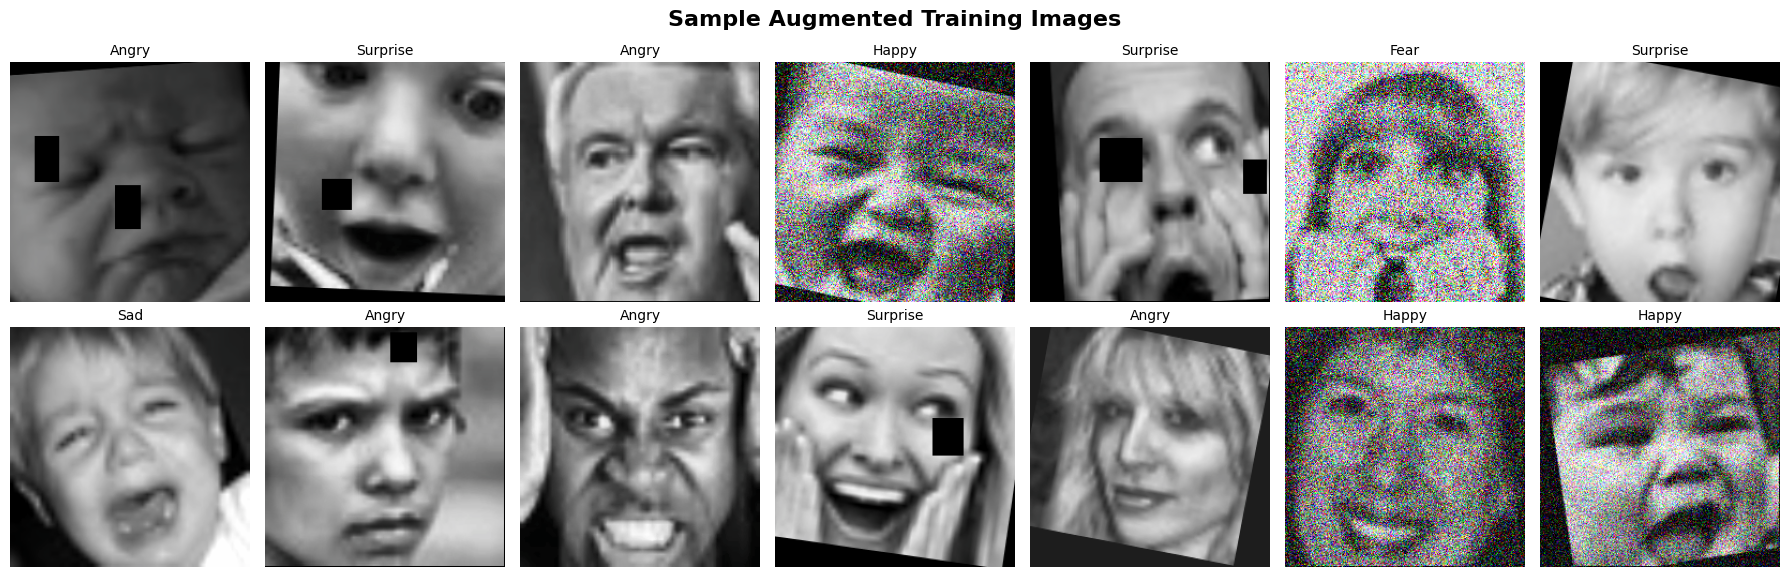

In [ ]:
# Visualize sample augmented images
fig, axes = plt.subplots(2, 7, figsize=(18, 6))
fig.suptitle('Sample Augmented Training Images', fontsize=16, fontweight='bold')

mean = np.array(cfg.MEAN)
std = np.array(cfg.STD)

for i in range(14):
    row, col = divmod(i, 7)
    img_t, lbl = train_dataset[random.randint(0, len(train_dataset)-1)]
    # Denormalize for display
    img_show = img_t.permute(1, 2, 0).numpy() * std + mean
    img_show = np.clip(img_show, 0, 1)
    axes[row, col].imshow(img_show)
    axes[row, col].set_title(cfg.EMOTION_LABELS[lbl.item()].capitalize(), fontsize=10)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

## 5. Model A: Vision Transformer (ViT)

**Why ViT is better than CNN for emotions:**
- Self-Attention captures long-range dependencies (eyes ↔ mouth ↔ eyebrows)
- CNNs need many stacked layers to connect distant facial regions
- Pretrained ImageNet features transfer very well

In [ ]:
class EmotionViT(nn.Module):
    """
    Vision Transformer for Facial Emotion Recognition.

    Architecture:
        ViT backbone (70% frozen) -> LayerNorm -> Dropout
        -> FC(512) -> GELU -> Dropout -> FC(7)
    """
    def __init__(self, model_name='vit_base_patch16_224',
                 num_classes=7, pretrained=True, drop_rate=0.3):
        super().__init__()

        # Load backbone without classification head
        self.backbone = timm.create_model(
            model_name, pretrained=pretrained,
            num_classes=0, drop_rate=0.1
        )
        feature_dim = self.backbone.num_features  # 768 for ViT-Base

        # Freeze first 70% of layers (early features are generic)
        all_params = list(self.backbone.parameters())
        freeze_count = int(len(all_params) * 0.7)
        for param in all_params[:freeze_count]:
            param.requires_grad = False

        # Custom classification head
        self.head = nn.Sequential(
            nn.LayerNorm(feature_dim),
            nn.Dropout(drop_rate),
            nn.Linear(feature_dim, 512),
            nn.GELU(),
            nn.Dropout(drop_rate * 0.7),
            nn.Linear(512, num_classes)
        )
        self._init_head()

    def _init_head(self):
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)


model_vit = EmotionViT(
    model_name=cfg.MODEL_NAME,
    num_classes=cfg.NUM_CLASSES,
    pretrained=True, drop_rate=0.3
).to(DEVICE)

total_p = sum(p.numel() for p in model_vit.parameters())
train_p = sum(p.numel() for p in model_vit.parameters() if p.requires_grad)
print(f"\nModel A: {cfg.MODEL_NAME}")
print(f"  Total params:     {total_p:>12,}")
print(f"  Trainable params: {train_p:>12,}")
print(f"  Frozen params:    {total_p - train_p:>12,}")

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            


Model A: vit_base_patch16_224
  Total params:       86,197,511
  Trainable params:   26,388,743
  Frozen params:      59,808,768


## 6. Model B: DAN (Distract Your Attention Network)

Multiple attention heads each focus on different facial regions (eyes, mouth, forehead).  
This prevents over-reliance on a single region.

In [ ]:
class AttentionHead(nn.Module):
    """Single attention head — focuses on one facial region."""
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(in_features, in_features // 4),
            nn.ReLU(),
            nn.Linear(in_features // 4, 1)
        )
        self.classifier = nn.Linear(in_features, num_classes)

    def forward(self, x):
        # x: (B, N, D) — N=spatial patches, D=feature dim
        attn_w = torch.softmax(self.attention(x).squeeze(-1), dim=1)
        attended = torch.bmm(attn_w.unsqueeze(1), x).squeeze(1)
        return self.classifier(attended), attn_w


class EmotionDAN(nn.Module):
    """
    DAN: EfficientNet-B2 backbone + 4 Attention Heads.
    Each head learns to attend to different facial regions.
    Final prediction = average of all heads.
    """
    def __init__(self, backbone_name='efficientnet_b2', num_classes=7,
                 num_heads=4, pretrained=True):
        super().__init__()

        self.backbone = timm.create_model(
            backbone_name, pretrained=pretrained,
            num_classes=0, global_pool=''
        )
        feature_dim = self.backbone.num_features

        # Freeze first 60%
        all_params = list(self.backbone.parameters())
        for param in all_params[:int(len(all_params) * 0.6)]:
            param.requires_grad = False

        self.num_heads = num_heads
        self.attention_heads = nn.ModuleList([
            AttentionHead(feature_dim, num_classes) for _ in range(num_heads)
        ])

    def forward(self, x):
        feat_map = self.backbone(x)                             # (B, D, H, W)
        B, D, H, W = feat_map.shape
        feat_flat = feat_map.reshape(B, D, H*W).permute(0, 2, 1)  # (B, N, D)

        outputs = [head(feat_flat)[0] for head in self.attention_heads]
        return torch.stack(outputs, dim=0).mean(dim=0)


model_dan = EmotionDAN(
    backbone_name='efficientnet_b2',
    num_classes=cfg.NUM_CLASSES,
    num_heads=4, pretrained=True
).to(DEVICE)

total_p2 = sum(p.numel() for p in model_dan.parameters())
train_p2 = sum(p.numel() for p in model_dan.parameters() if p.requires_grad)
print(f"\nModel B: DAN (EfficientNet-B2 + 4 Attention Heads)")
print(f"  Total params:     {total_p2:>12,}")
print(f"  Trainable params: {train_p2:>12,}")

model.safetensors: reconstructing file:   0%|          |  0.00B / 36.8MB            

model.safetensors: downloading bytes:           |  0.00B            


Model B: DAN (EfficientNet-B2 + 4 Attention Heads)
  Total params:        9,725,730
  Trainable params:    8,783,606


## 7. Mixup & CutMix

In [ ]:
def mixup_data(x, y, alpha=0.4):
    """Mixup: blend two images with random ratio."""
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    lam = max(lam, 1 - lam)
    index = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    return mixed_x, y, y[index], lam


def cutmix_data(x, y, alpha=1.0):
    """CutMix: cut a rectangle from one image and paste into another."""
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0), device=x.device)
    _, _, H, W = x.shape
    cut_ratio = np.sqrt(1.0 - lam)
    cut_h, cut_w = int(H * cut_ratio), int(W * cut_ratio)
    cy, cx = np.random.randint(H), np.random.randint(W)
    y1 = np.clip(cy - cut_h // 2, 0, H)
    y2 = np.clip(cy + cut_h // 2, 0, H)
    x1 = np.clip(cx - cut_w // 2, 0, W)
    x2 = np.clip(cx + cut_w // 2, 0, W)
    mixed_x = x.clone()
    mixed_x[:, :, y1:y2, x1:x2] = x[index, :, y1:y2, x1:x2]
    lam = 1 - ((y2-y1) * (x2-x1)) / (H * W)
    return mixed_x, y, y[index], lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Compute mixed loss."""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


print("Mixup + CutMix ready")

Mixup + CutMix ready


## 8. Training Loop

Combines all optimizations:
- Mixed Precision (AMP)
- Cosine Annealing LR with Warm Restarts
- Label Smoothing
- Mixup + CutMix
- Gradient Clipping
- Early Stopping

In [ ]:
class Trainer:
    def __init__(self, model, model_name, cfg, device):
        self.model = model
        self.model_name = model_name
        self.cfg = cfg
        self.device = device
        self.best_val_acc = 0
        self.history = {
            'train_loss': [], 'val_loss': [],
            'train_acc': [], 'val_acc': [], 'lr': []
        }

        # Loss with label smoothing
        self.criterion = nn.CrossEntropyLoss(label_smoothing=cfg.LABEL_SMOOTHING)

        # Optimizer (only trainable params)
        self.optimizer = AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY
        )

        # LR Scheduler
        self.scheduler = CosineAnnealingWarmRestarts(
            self.optimizer, T_0=10, T_mult=2, eta_min=1e-7
        )

        # Mixed Precision scaler
        self.scaler = torch.amp.GradScaler() if cfg.USE_MIXED_PREC else None

    def _apply_mix(self, images, labels):
        """Randomly apply Mixup or CutMix."""
        if random.random() < self.cfg.MIXUP_PROB:
            if random.random() < 0.5:
                return mixup_data(images, labels, self.cfg.MIXUP_ALPHA)
            else:
                return cutmix_data(images, labels, self.cfg.CUTMIX_ALPHA)
        return images, labels, labels, 1.0

    def train_epoch(self, loader):
        self.model.train()
        running_loss, correct, total = 0, 0, 0

        pbar = tqdm(loader, desc='Training', leave=False)
        for images, labels in pbar:
            images = images.to(self.device, non_blocking=True)
            labels = labels.to(self.device, non_blocking=True)

            # Mixup / CutMix
            mixed_img, labels_a, labels_b, lam = self._apply_mix(images, labels)

            self.optimizer.zero_grad()

            if self.cfg.USE_MIXED_PREC:
                with torch.amp.autocast(device_type='cuda'):
                    outputs = self.model(mixed_img)
                    loss = mixup_criterion(self.criterion, outputs, labels_a, labels_b, lam)
                self.scaler.scale(loss).backward()
                self.scaler.unscale_(self.optimizer)
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                self.scaler.step(self.optimizer)
                self.scaler.update()
            else:
                outputs = self.model(mixed_img)
                loss = mixup_criterion(self.criterion, outputs, labels_a, labels_b, lam)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                self.optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            correct += (lam * preds.eq(labels_a).sum().item() +
                        (1-lam) * preds.eq(labels_b).sum().item())
            total += labels.size(0)
            pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{correct/total:.4f}'})

        return running_loss / total, correct / total

    @torch.no_grad()
    def validate(self, loader):
        self.model.eval()
        running_loss, correct, total = 0, 0, 0

        for images, labels in loader:
            images = images.to(self.device, non_blocking=True)
            labels = labels.to(self.device, non_blocking=True)

            if self.cfg.USE_MIXED_PREC:
                with torch.amp.autocast(device_type='cuda'):
                    outputs = self.model(images)
                    loss = self.criterion(outputs, labels)
            else:
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            correct += outputs.argmax(1).eq(labels).sum().item()
            total += labels.size(0)

        return running_loss / total, correct / total

    def fit(self, train_loader, val_loader, epochs):
        print(f"\n{'='*65}")
        print(f"  Training: {self.model_name}")
        print(f"  Epochs: {epochs} | LR: {self.cfg.LR} | AMP: {self.cfg.USE_MIXED_PREC}")
        print(f"{'='*65}\n")

        patience, no_improve = 12, 0

        for epoch in range(1, epochs + 1):
            train_loss, train_acc = self.train_epoch(train_loader)
            val_loss, val_acc = self.validate(val_loader)
            self.scheduler.step()
            lr = self.optimizer.param_groups[0]['lr']

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_acc'].append(val_acc)
            self.history['lr'].append(lr)

            marker = ''
            if val_acc > self.best_val_acc:
                self.best_val_acc = val_acc
                torch.save(self.model.state_dict(), f'best_{self.model_name}.pth')
                marker = ' << BEST'
                no_improve = 0
            else:
                no_improve += 1

            print(f"Epoch {epoch:02d}/{epochs} | "
                  f"Train: {train_acc:.4f} ({train_loss:.4f}) | "
                  f"Val: {val_acc:.4f} ({val_loss:.4f}) | "
                  f"LR: {lr:.2e}{marker}")

            if no_improve >= patience:
                print(f"\n  Early Stopping: no improvement for {patience} epochs")
                break

        # Load best weights
        self.model.load_state_dict(
            torch.load(f'best_{self.model_name}.pth', weights_only=True)
        )
        print(f"\n  Best Val Accuracy: {self.best_val_acc:.4f} ({self.best_val_acc*100:.2f}%)")
        return self.history

In [ ]:
# ===================== TRAIN MODEL A: ViT =====================

trainer_vit = Trainer(model_vit, 'ViT_emotion', cfg, DEVICE)
history_vit = trainer_vit.fit(train_loader, val_loader, cfg.EPOCHS)


  Training: ViT_emotion
  Epochs: 40 | LR: 3e-05 | AMP: True



Training:   0%|          | 0/809 [00:00<?, ?it/s]

Epoch 01/40 | Train: 0.4656 (1.5369) | Val: 0.6427 (1.1823) | LR: 2.93e-05 << BEST


Training:   0%|          | 0/809 [00:00<?, ?it/s]

Epoch 02/40 | Train: 0.5384 (1.4002) | Val: 0.6506 (1.1686) | LR: 2.71e-05 << BEST


...

Training:   0%|          | 0/809 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c3eb6f8b240>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7c3eb6f8b240>^
^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
^^    ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
^^    ^if w.is_alive():
^ ^ ^ ^ ^ ^  ^Except

Epoch 39/40 | Train: 0.7628 (0.9743) | Val: 0.7126 (1.2364) | LR: 2.64e-05


Training:   0%|          | 0/809 [00:00<?, ?it/s]

Epoch 40/40 | Train: 0.7605 (0.9760) | Val: 0.7095 (1.2392) | LR: 2.56e-05

  Best Val Accuracy: 0.7149 (71.49%)


In [ ]:
# ===================== TRAIN MODEL B: DAN =====================

trainer_dan = Trainer(model_dan, 'DAN_emotion', cfg, DEVICE)
history_dan = trainer_dan.fit(train_loader, val_loader, cfg.EPOCHS)


  Training: DAN_emotion
  Epochs: 40 | LR: 3e-05 | AMP: True



Training:   0%|          | 0/809 [00:00<?, ?it/s]

Epoch 01/40 | Train: 0.3456 (1.7336) | Val: 0.5439 (1.3816) | LR: 2.93e-05 << BEST


Training:   0%|          | 0/809 [00:00<?, ?it/s]

Epoch 02/40 | Train: 0.4463 (1.5666) | Val: 0.5982 (1.2679) | LR: 2.71e-05 << BEST


...

Epoch 38/40 | Train: 0.6756 (1.1411) | Val: 0.7078 (1.0924) | LR: 2.71e-05


Training:   0%|          | 0/809 [00:00<?, ?it/s]

Epoch 39/40 | Train: 0.6836 (1.1335) | Val: 0.7081 (1.0791) | LR: 2.64e-05


Training:   0%|          | 0/809 [00:00<?, ?it/s]

Epoch 40/40 | Train: 0.6884 (1.1226) | Val: 0.7101 (1.0908) | LR: 2.56e-05 << BEST

  Best Val Accuracy: 0.7101 (71.01%)


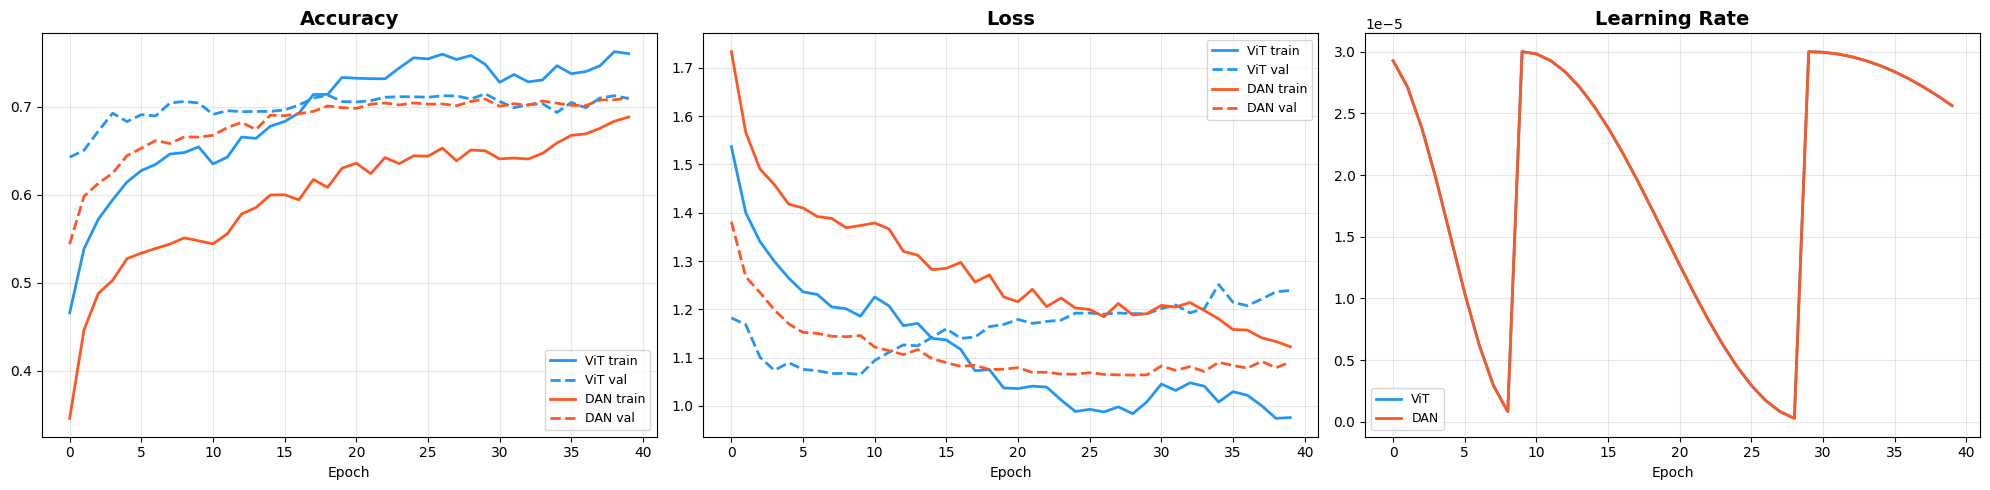

In [ ]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
colors = ['#2196F3', '#FF5722']
names = ['ViT', 'DAN']
histories = [history_vit, history_dan]

for i, (h, name) in enumerate(zip(histories, names)):
    c = colors[i]
    axes[0].plot(h['train_acc'], label=f'{name} train', color=c, linewidth=2)
    axes[0].plot(h['val_acc'], label=f'{name} val', color=c, linewidth=2, linestyle='--')
    axes[1].plot(h['train_loss'], label=f'{name} train', color=c, linewidth=2)
    axes[1].plot(h['val_loss'], label=f'{name} val', color=c, linewidth=2, linestyle='--')
    axes[2].plot(h['lr'], label=name, color=c, linewidth=2)

for ax, title in zip(axes, ['Accuracy', 'Loss', 'Learning Rate']):
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Epoch')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## 9. Test-Time Augmentation + Ensemble

In [ ]:
# ================================================================
#  TTA: predict with multiple augmented versions
# ================================================================

def get_tta_transform_list(img_size=224):
    """6 deterministic TTA transforms using torchvision (works everywhere)."""
    norm = T.Normalize(mean=Config.MEAN, std=Config.STD)
    base = [T.ToPILImage(), T.Resize((img_size, img_size))]

    return [
        T.Compose(base + [T.ToTensor(), norm]),                                       # Original
        T.Compose(base + [T.RandomHorizontalFlip(p=1.0), T.ToTensor(), norm]),        # Flipped
        T.Compose(base + [T.RandomAffine(0, translate=(0.05, 0)), T.ToTensor(), norm]),  # Shift right
        T.Compose(base + [T.RandomAffine(0, translate=(0.05, 0)), T.ToTensor(), norm]), # Shift left,
        T.Compose(base + [T.RandomRotation((8, 8)), T.ToTensor(), norm]),             # Rotate +8
        T.Compose(base + [T.RandomRotation((-8, -8)), T.ToTensor(), norm]),           # Rotate -8
    ]


@torch.no_grad()
def predict_with_tta(model, image_paths, labels, device, batch_size=32):
    """Predict using TTA — average predictions across all transforms."""
    model.eval()
    tta_transforms = get_tta_transform_list(cfg.IMG_SIZE)
    all_probs = []

    for t_idx, tfm in enumerate(tta_transforms):
        # Build dataset with this specific transform
        ds = EmotionDataset(
            image_paths, labels, transform=tfm,
            face_aligner=face_aligner, use_alignment=cfg.USE_FACE_ALIGN
        )
        loader = DataLoader(ds, batch_size=batch_size, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)

        batch_probs = []
        for images, _ in loader:
            images = images.to(device, non_blocking=True)
            if cfg.USE_MIXED_PREC:
                with torch.amp.autocast(device_type='cuda'):
                    logits = model(images)
            else:
                logits = model(images)
            probs = F.softmax(logits, dim=1)
            batch_probs.append(probs.cpu().numpy())

        all_probs.append(np.concatenate(batch_probs))
        print(f"  TTA {t_idx+1}/{len(tta_transforms)} done")

    return np.mean(all_probs, axis=0)

In [ ]:
# Run TTA on both models
if cfg.USE_TTA:
    print("\n=== TTA: ViT ===")
    probs_vit = predict_with_tta(model_vit, test_paths, test_labels, DEVICE)

    print("\n=== TTA: DAN ===")
    probs_dan = predict_with_tta(model_dan, test_paths, test_labels, DEVICE)
else:
    # Standard prediction without TTA
    model_vit.eval(); model_dan.eval()
    pv, pd = [], []
    for images, _ in test_loader:
        images = images.to(DEVICE)
        with torch.no_grad():
            pv.append(F.softmax(model_vit(images), dim=1).cpu().numpy())
            pd.append(F.softmax(model_dan(images), dim=1).cpu().numpy())
    probs_vit = np.concatenate(pv)
    probs_dan = np.concatenate(pd)

print("\nPredictions ready")


=== TTA: ViT ===
  TTA 1/6 done
  TTA 2/6 done
  TTA 3/6 done
  TTA 4/6 done
  TTA 5/6 done
  TTA 6/6 done

=== TTA: DAN ===
  TTA 1/6 done
  TTA 2/6 done
  TTA 3/6 done
  TTA 4/6 done
  TTA 5/6 done
  TTA 6/6 done

Predictions ready


In [ ]:
# ================================================================
#  Ensemble: combine both models
# ================================================================

# Validation-accuracy-based weights
w_vit = trainer_vit.best_val_acc
w_dan = trainer_dan.best_val_acc
w_sum = w_vit + w_dan
w_vit_n, w_dan_n = w_vit / w_sum, w_dan / w_sum

results = {}

# 1. ViT only
pred_vit = np.argmax(probs_vit, axis=1)
results['ViT Only'] = accuracy_score(test_labels, pred_vit)

# 2. DAN only
pred_dan = np.argmax(probs_dan, axis=1)
results['DAN Only'] = accuracy_score(test_labels, pred_dan)

# 3. Simple Average Ensemble
ens_avg = (probs_vit + probs_dan) / 2
pred_avg = np.argmax(ens_avg, axis=1)
results['Ensemble (Average)'] = accuracy_score(test_labels, pred_avg)

# 4. Weighted Average Ensemble
ens_w = w_vit_n * probs_vit + w_dan_n * probs_dan
pred_w = np.argmax(ens_w, axis=1)
results['Ensemble (Weighted)'] = accuracy_score(test_labels, pred_w)

# Print comparison
print(f"\n{'='*60}")
print(f"  RESULTS COMPARISON")
print(f"{'='*60}")
print(f"{'Method':<30} {'Accuracy':>10} {'F1 (Wt.)':>10}")
print(f"{'-'*60}")

for method, acc in results.items():
    p = {'ViT Only': pred_vit, 'DAN Only': pred_dan,
         'Ensemble (Average)': pred_avg, 'Ensemble (Weighted)': pred_w}[method]
    f1 = f1_score(test_labels, p, average='weighted')
    print(f"  {method:<28} {acc:>9.4f} {f1:>10.4f}")

best_method = max(results, key=results.get)
best_acc = results[best_method]
print(f"{'='*60}")
print(f"  BEST: {best_method} -> {best_acc:.4f} ({best_acc*100:.2f}%)")
print(f"{'='*60}")

# Select best predictions
best_map = {'Ensemble (Weighted)': (pred_w, ens_w), 'Ensemble (Average)': (pred_avg, ens_avg),
            'ViT Only': (pred_vit, probs_vit), 'DAN Only': (pred_dan, probs_dan)}
final_pred, final_probs = best_map[best_method]


  RESULTS COMPARISON
Method                           Accuracy   F1 (Wt.)
------------------------------------------------------------
  ViT Only                        0.7188     0.7178
  DAN Only                        0.7089     0.7074
  Ensemble (Average)              0.7356     0.7343
  Ensemble (Weighted)             0.7357     0.7345
  BEST: Ensemble (Weighted) -> 0.7357 (73.57%)


## 10. Detailed Evaluation

In [ ]:
# Classification Report
final_acc = accuracy_score(test_labels, final_pred)
final_f1 = f1_score(test_labels, final_pred, average='weighted')

print(f"\n  Final Accuracy:     {final_acc:.4f} ({final_acc*100:.2f}%)")
print(f"  Final Weighted F1:  {final_f1:.4f}\n")

print(classification_report(
    test_labels, final_pred,
    target_names=[e.capitalize() for e in cfg.EMOTION_LABELS],
    digits=4
))


  Final Accuracy:     0.7357 (73.57%)
  Final Weighted F1:  0.7345

              precision    recall  f1-score   support

       Angry     0.6335    0.6426    0.6380       971
     Disgust     0.9520    0.9436    0.9477       567
        Fear     0.6197    0.5456    0.5803       911
       Happy     0.8922    0.8956    0.8939      1599
     Neutral     0.6466    0.7180    0.6805      1259
         Sad     0.6438    0.6065    0.6246      1240
    Surprise     0.8000    0.8272    0.8134       793

    accuracy                         0.7357      7340
   macro avg     0.7411    0.7399    0.7398      7340
weighted avg     0.7347    0.7357    0.7345      7340



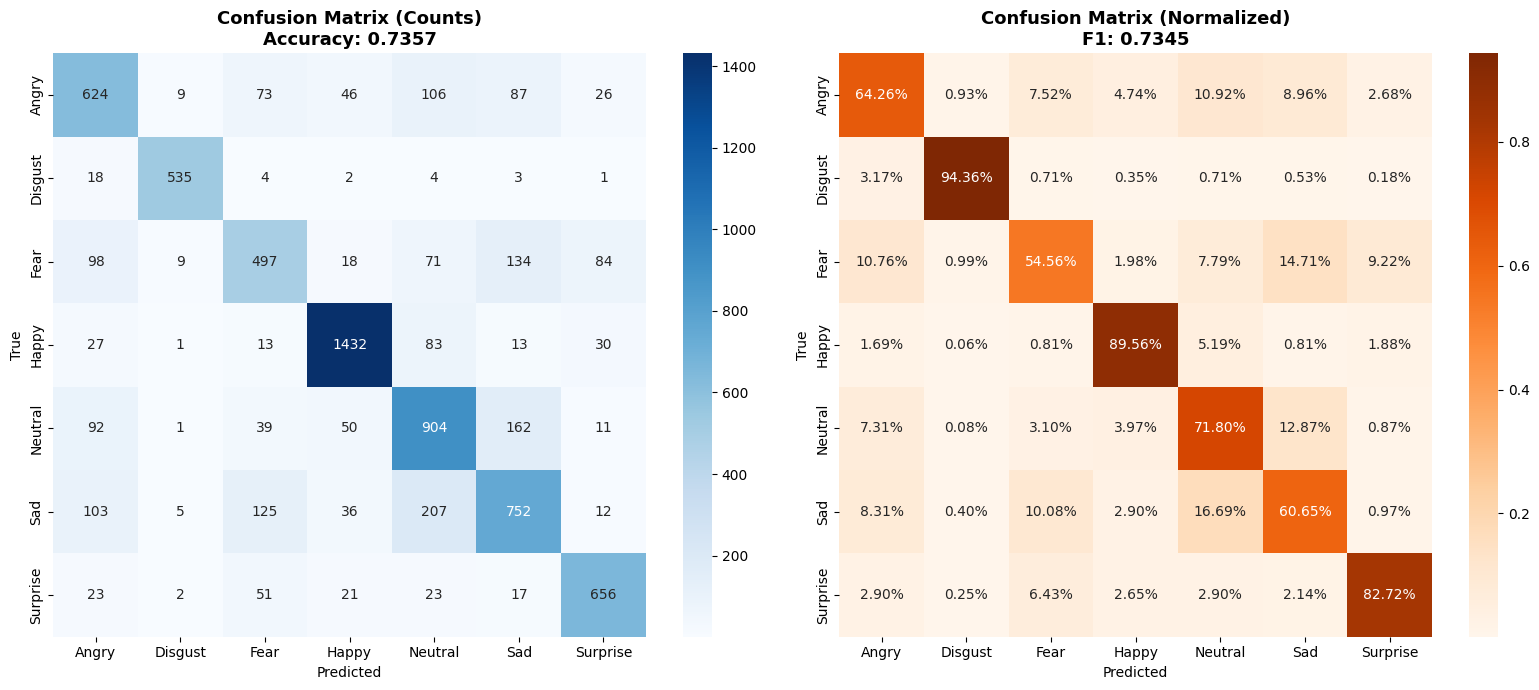

In [ ]:
# Confusion Matrix
cm = confusion_matrix(test_labels, final_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
labels_cap = [e.capitalize() for e in cfg.EMOTION_LABELS]

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_cap, yticklabels=labels_cap, ax=axes[0])
axes[0].set_title(f'Confusion Matrix (Counts)\nAccuracy: {final_acc:.4f}',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Oranges',
            xticklabels=labels_cap, yticklabels=labels_cap, ax=axes[1])
axes[1].set_title(f'Confusion Matrix (Normalized)\nF1: {final_f1:.4f}',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

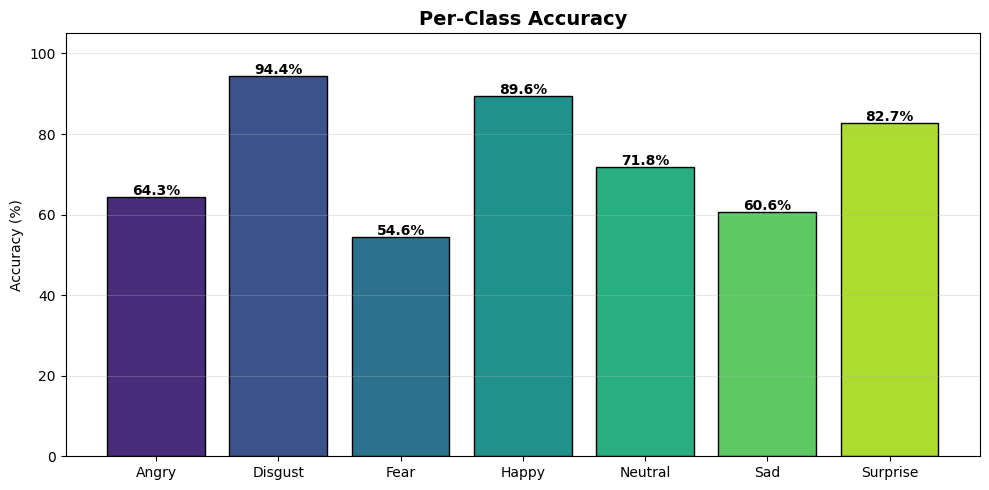

In [ ]:
# Per-class accuracy bar chart
per_class = cm_norm.diagonal()

plt.figure(figsize=(10, 5))
bars = plt.bar(labels_cap, per_class * 100,
               color=sns.color_palette('viridis', cfg.NUM_CLASSES), edgecolor='black')
for b, a in zip(bars, per_class):
    plt.text(b.get_x() + b.get_width()/2, b.get_height()+0.5,
             f'{a*100:.1f}%', ha='center', fontweight='bold')
plt.title('Per-Class Accuracy', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Grad-CAM / Attention Maps

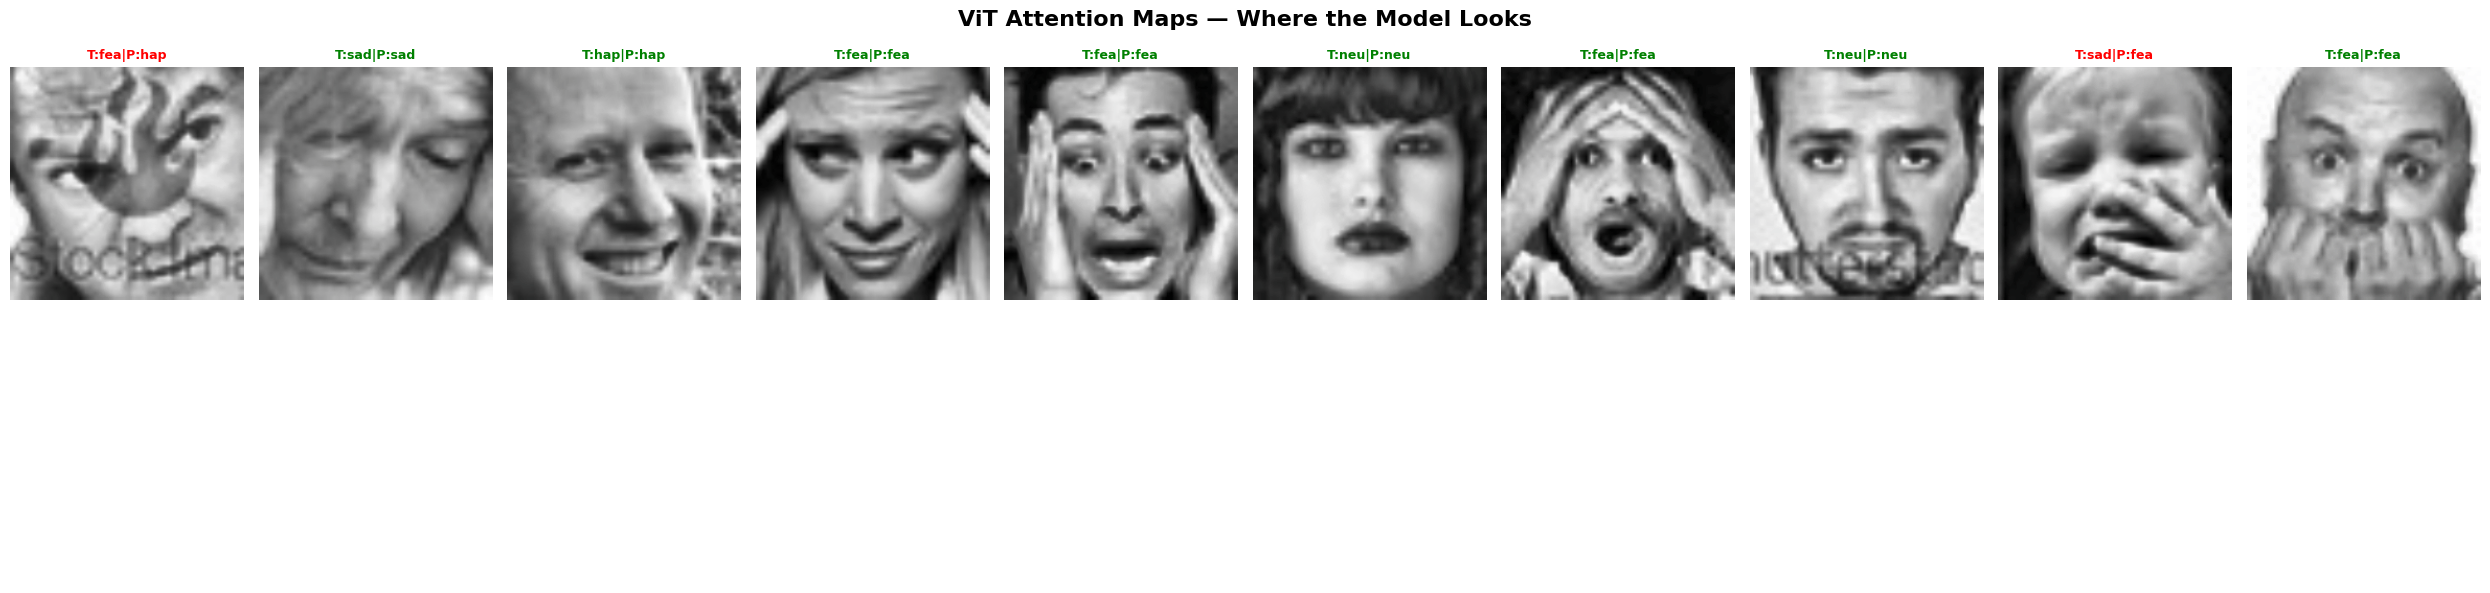

In [ ]:
def get_vit_attention_map(model, image_tensor, device):
    """Extract attention map from ViT using Attention Rollout."""
    model.eval()
    img = image_tensor.unsqueeze(0).to(device)

    attention_maps = []
    hooks = []

    def hook_fn(module, input, output):
        if hasattr(output, 'shape') and len(output.shape) == 3:
            attention_maps.append(output.detach())

    for name, module in model.backbone.named_modules():
        if 'attn_drop' in name:
            hooks.append(module.register_forward_hook(hook_fn))

    with torch.no_grad():
        _ = model(img)

    for h in hooks:
        h.remove()

    if not attention_maps:
        return None

    # Attention Rollout
    result = torch.eye(attention_maps[0].shape[-1], device=device)
    for attn in attention_maps:
        attn = attn.mean(dim=1)
        attn = attn + torch.eye(attn.shape[-1], device=device)
        attn = attn / attn.sum(dim=-1, keepdim=True)
        result = torch.matmul(attn, result)

    mask = result[0, 0, 1:]  # Skip CLS token
    grid_size = int(np.sqrt(len(mask)))
    mask = mask.reshape(grid_size, grid_size).cpu().numpy()
    mask = cv2.resize(mask, (cfg.IMG_SIZE, cfg.IMG_SIZE))
    mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)
    return mask


# Visualize attention maps
n_show = min(10, len(test_dataset))
indices = random.sample(range(len(test_dataset)), n_show)
fig, axes = plt.subplots(2, n_show, figsize=(2.5 * n_show, 6))
fig.suptitle('ViT Attention Maps — Where the Model Looks', fontsize=16, fontweight='bold')

mean_np = np.array(cfg.MEAN)
std_np = np.array(cfg.STD)

for col, idx in enumerate(indices):
    img_t, label = test_dataset[idx]
    img_show = img_t.permute(1, 2, 0).numpy() * std_np + mean_np
    img_show = np.clip(img_show, 0, 1)

    with torch.no_grad():
        pred_idx = model_vit(img_t.unsqueeze(0).to(DEVICE)).argmax(1).item()

    color = 'green' if pred_idx == label.item() else 'red'
    axes[0, col].imshow(img_show)
    axes[0, col].set_title(
        f'T:{cfg.EMOTION_LABELS[label][:3]}|P:{cfg.EMOTION_LABELS[pred_idx][:3]}',
        fontsize=9, color=color, fontweight='bold')
    axes[0, col].axis('off')

    attn_map = get_vit_attention_map(model_vit, img_t, DEVICE)
    if attn_map is not None:
        axes[1, col].imshow(img_show)
        axes[1, col].imshow(attn_map, cmap='jet', alpha=0.5)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=12)
axes[1, 0].set_ylabel('Attention', fontsize=12)
plt.tight_layout()
plt.savefig('attention_maps.png', dpi=150)
plt.show()

## 12. Knowledge Distillation — Fast Model for Real-Time

- **Teacher:** ViT + DAN ensemble (large, accurate)
- **Student:** MobileNetV3-Small (tiny, fast, runs on CPU)

In [ ]:
student = StudentModel().to(DEVICE)

print(student.backbone.num_features)

576


In [ ]:
x = torch.randn(1, 3, cfg.IMG_SIZE, cfg.IMG_SIZE).to(DEVICE)

with torch.no_grad():
    y = student.backbone(x)

print(y.shape)

torch.Size([1, 1024])


In [ ]:
class StudentModel(nn.Module):
    """MobileNetV3-Small — fast enough for real-time on CPU."""
    def __init__(self, num_classes=7, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            'mobilenetv3_small_100', pretrained=pretrained, num_classes=0
        )
        self.head = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(1024, num_classes)
        )

    def forward(self, x):
        return self.head(self.backbone(x))


class DistillationLoss(nn.Module):
    """Combines hard (label) loss with soft (teacher) loss."""
    def __init__(self, temperature=4.0, alpha=0.7):
        super().__init__()
        self.T = temperature
        self.alpha = alpha
        self.hard_loss = nn.CrossEntropyLoss(label_smoothing=0.1)
        self.kl_loss = nn.KLDivLoss(reduction='batchmean')

    def forward(self, student_logits, teacher_logits, labels):
        hard = self.hard_loss(student_logits, labels)
        soft_s = F.log_softmax(student_logits / self.T, dim=1)
        soft_t = F.softmax(teacher_logits / self.T, dim=1)
        soft = self.kl_loss(soft_s, soft_t) * (self.T ** 2)
        return self.alpha * soft + (1 - self.alpha) * hard

In [ ]:
if cfg.USE_DISTILLATION:
    student = StudentModel(cfg.NUM_CLASSES).to(DEVICE)
    dist_loss = DistillationLoss(temperature=4.0, alpha=0.7)
    st_optimizer = AdamW(student.parameters(), lr=1e-3, weight_decay=0.01)
    st_scheduler = CosineAnnealingWarmRestarts(st_optimizer, T_0=5, T_mult=2)

    s_p = sum(p.numel() for p in student.parameters())
    t_p = sum(p.numel() for p in model_vit.parameters())
    print(f"Teacher (ViT):       {t_p:>12,} params")
    print(f"Student (MobileNet): {s_p:>12,} params")
    print(f"Compression:         {t_p/s_p:.1f}x smaller")

    # Distillation training
    model_vit.eval()
    model_dan.eval()
    best_student_acc = 0
    DISTILL_EPOCHS = 25

    print(f"\nDistillation training ({DISTILL_EPOCHS} epochs)...\n")

    for epoch in range(1, DISTILL_EPOCHS + 1):
        student.train()
        correct, total = 0, 0

        for images, labels in tqdm(train_loader, desc=f'Distill {epoch}', leave=False):
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            # Teacher predictions (no gradient)
            with torch.no_grad():
                t_vit = model_vit(images)
                t_dan = model_dan(images)
                teacher_logits = w_vit_n * t_vit + w_dan_n * t_dan

            student_logits = student(images)
            loss = dist_loss(student_logits, teacher_logits, labels)

            st_optimizer.zero_grad()
            loss.backward()
            st_optimizer.step()

            correct += student_logits.argmax(1).eq(labels).sum().item()
            total += labels.size(0)

        st_scheduler.step()

        # Validate student
        student.eval()
        vc, vt = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                vc += student(images).argmax(1).eq(labels).sum().item()
                vt += labels.size(0)

        val_acc = vc / vt
        marker = ''
        if val_acc > best_student_acc:
            best_student_acc = val_acc
            torch.save(student.state_dict(), 'best_student.pth')
            marker = ' << BEST'

        print(f"Epoch {epoch:02d} | Train: {correct/total:.4f} | Val: {val_acc:.4f}{marker}")

    student.load_state_dict(torch.load('best_student.pth', weights_only=True))
    print(f"\nStudent best val acc: {best_student_acc:.4f} ({best_student_acc*100:.2f}%)")

Teacher (ViT):         86,197,511 params
Student (MobileNet):    1,525,031 params
Compression:         56.5x smaller

Distillation training (25 epochs)...



Distill 1:   0%|          | 0/809 [00:00<?, ?it/s]

Epoch 01 | Train: 0.4086 | Val: 0.4975 << BEST


Distill 2:   0%|          | 0/809 [00:00<?, ?it/s]

Epoch 02 | Train: 0.5397 | Val: 0.5563 << BEST


...

Epoch 23 | Train: 0.7296 | Val: 0.6928


Distill 24:   0%|          | 0/809 [00:00<?, ?it/s]

Epoch 24 | Train: 0.7392 | Val: 0.6954


Distill 25:   0%|          | 0/809 [00:00<?, ?it/s]

Epoch 25 | Train: 0.7545 | Val: 0.7053 << BEST

Student best val acc: 0.7053 (70.53%)


## 13. Save All Models

In [ ]:
print("Saving models...\n")

# Full checkpoint with config
torch.save({
    'model_state': model_vit.state_dict(),
    'model_name': cfg.MODEL_NAME,
    'num_classes': cfg.NUM_CLASSES,
    'img_size': cfg.IMG_SIZE,
    'emotions': cfg.EMOTION_LABELS,
    'best_val_acc': trainer_vit.best_val_acc
}, 'vit_emotion_full.pth')
print("  vit_emotion_full.pth")

torch.save({
    'model_state': model_dan.state_dict(),
    'num_classes': cfg.NUM_CLASSES,
    'best_val_acc': trainer_dan.best_val_acc
}, 'dan_emotion_full.pth')
print("  dan_emotion_full.pth")

if cfg.USE_DISTILLATION:
    torch.save({
        'model_state': student.state_dict(),
        'num_classes': cfg.NUM_CLASSES
    }, 'student_mobilenet_full.pth')
    print("  student_mobilenet_full.pth")

# ONNX export for deployment
try:
    dummy = torch.randn(1, 3, cfg.IMG_SIZE, cfg.IMG_SIZE, device=DEVICE)
    export_model = student if cfg.USE_DISTILLATION else model_vit
    export_model.eval()
    torch.onnx.export(export_model, dummy, 'emotion_model.onnx', opset_version=14)
    print("  emotion_model.onnx")
except Exception as e:
    print(f"  ONNX export skipped: {e}")

print("\nAll models saved!")

Saving models...

  vit_emotion_full.pth
  dan_emotion_full.pth
  student_mobilenet_full.pth
  ONNX export skipped: No module named 'onnxscript'

All models saved!


## 14. Real-Time Webcam Detection

In [ ]:
def run_webcam(model, device, img_size=224):
    """
    Real-time webcam emotion detection with:
    - Haar Cascade face detection
    - CLAHE contrast enhancement
    - Temporal smoothing (buffer of 7 frames)
    - Confidence bars overlay

    Press 'q' to quit.
    """
    model.eval()
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    )
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))

    mean_t = torch.tensor(cfg.MEAN).view(3, 1, 1).to(device)
    std_t = torch.tensor(cfg.STD).view(3, 1, 1).to(device)

    emotion_colors = {
        'angry': (0,0,255), 'disgust': (0,128,0), 'fear': (128,0,128),
        'happy': (0,255,255), 'neutral': (200,200,200), 'sad': (255,0,0),
        'surprise': (0,165,255)
    }

    pred_buffer = []
    BUFFER_SIZE = 7

    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("ERROR: Cannot open webcam")
        return

    print("Webcam started. Press 'q' to quit.")

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, 1.3, 5, minSize=(48, 48))

        for (x, y, w, h) in faces:
            # Crop and preprocess face
            face = frame[y:y+h, x:x+w]
            face_rgb = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
            face_resized = cv2.resize(face_rgb, (img_size, img_size))

            # CLAHE on L channel
            lab = cv2.cvtColor(face_resized, cv2.COLOR_RGB2LAB)
            lab[:,:,0] = clahe.apply(lab[:,:,0])
            face_enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

            # To tensor + normalize
            img_t = torch.from_numpy(face_enhanced).permute(2, 0, 1).float().to(device) / 255.0
            img_t = (img_t - mean_t) / std_t
            img_t = img_t.unsqueeze(0)

            with torch.no_grad():
                probs = F.softmax(model(img_t), dim=1).cpu().numpy()[0]

            # Temporal smoothing
            pred_buffer.append(probs)
            if len(pred_buffer) > BUFFER_SIZE:
                pred_buffer.pop(0)
            smoothed = np.mean(pred_buffer, axis=0)

            pred_idx = np.argmax(smoothed)
            emotion = cfg.EMOTION_LABELS[pred_idx]
            conf = smoothed[pred_idx] * 100
            color = emotion_colors.get(emotion, (0, 255, 0))

            # Draw bounding box + label
            cv2.rectangle(frame, (x, y), (x+w, y+h), color, 2)
            cv2.putText(frame, f"{emotion.upper()}: {conf:.0f}%",
                        (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

            # Confidence bars
            for i, (emo, prob) in enumerate(zip(cfg.EMOTION_LABELS, smoothed)):
                bar_y = 30 + i * 28
                bar_w = int(prob * 180)
                c = emotion_colors.get(emo, (150, 150, 150))
                cv2.rectangle(frame, (10, bar_y), (10+bar_w, bar_y+20), c, -1)
                cv2.putText(frame, f"{emo}: {prob*100:.0f}%", (195, bar_y+15),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)

        cv2.imshow('Emotion Recognition (q to quit)', frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()
    print("Webcam stopped.")

In [ ]:
import os
for f in os.listdir():
    if f.endswith(".pth"):
        print(f)

best_ViT_emotion.pth
dan_emotion_full.pth
best_DAN_emotion.pth
vit_emotion_full.pth
best_student.pth
student_mobilenet_full.pth
